# Определение возраста покупателей

# О проекте

**Описание проекта**

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы (первая задача);
- Контролировать добросовестность кассиров при продаже алкоголя (вторая задача модели).

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста, в статье о котором значение MAE равно 5.4.

**Цель проекта**

Построить модель, которая по фотографии определит приблизительный возраст человека. Согласно требованию к проекту, метрикой качества для нее будет MAE, и она должна быть меньше 8. Результат же меньше 7 будет считаться отличным.

**План проекта**

- Провести исследовательский анализ набора фотографий.
- Подготовить данные к обучению.
- Обучите нейронную сеть и рассчитайте её качество.

**Описание данных**

Данные взяты с сайта ChaLearn Looking at People. Они находятся в папке `'/datasets/faces/'`.

В нашем распоряжении одна папка со всеми изображениями (`'/final_files'`) и CSV-файл `'labels.csv'` с двумя колонками:
- `'file_name'` - имя файла с фотографией;
- `'real_age'` - приблизительный возраст.

# Загрузка библиотек и установление констант

Прежде чем приступать к работе, нам необходимо подготовить удобную среду и инструменты.

In [ ]:
# загрузка библиотек
import pandas as pd # работа с данными в формате таблиц
import numpy as np  # математические операции и работа с массивами

# визуализация
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков

# библиотеки для работы с компьютерным зрением
from tensorflow.keras.models import Sequential # базовый класс для создания модели нейронной сети в Keras
# компоненты сети
from tensorflow.keras.layers import (
                                     #Conv2D, # двумерная свертка
                                     #MaxPooling2D, # один из вариантов пулинга
                                     #AveragePooling2D, # второй вариант
                                     GlobalAveragePooling2D, # для RusNet
                                     #Flatten, # слой, преобразующий многомерный тензор в одномерный
                                     Dense, # тип слоя (полносвязный), выполняет линейную операцию над входными данными
                                     #Dropout, # слой, случайно выключающий некоторые нейроны, помогает предотвратить переобучение модели
                                     #BatchNormalization # слой нормализации партии, который нормализует входные данные по мини-партии
                                     # слой активации, который применяет функцию активации к входным данным,
                                     # Activation # но можно без данного импорта определять прямо в слоях
                                     )

from tensorflow.keras.optimizers import Adam # загружаем оптимизатор отдельно, чтобы иметь возможность настройки
from tensorflow.keras.applications.resnet import ResNet50 # импорт ResNet (одна из готовых стуктур нейросети)
from tensorflow.keras.preprocessing.image import ImageDataGenerator # загрузчик данных для изображений

In [ ]:
# задание констант
RANDOM_STATE=12345
LOSS='mean_squared_error'
METRICS=['mean_absolute_error']
TEST_SIZE=0.25

In [ ]:
# задаем настройки отображения

# настройки дисплея
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format

# настройки графиков библиотеки sns
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

# выключение предупреждений
# фильтр для предупреждений игнора всех предупреждения категории FutureWarning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#pd.options.mode.chained_assignment = None # предупреждения о связанном назначении в pandas

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

**Вывод**

Требуемые для работы библиотеки загружены, константы определены, настойки отображения заданы.

# Исследовательский анализ данных

Наши данные состоят из двух частей: папка со всеми изображениями и CSV-файл. Поэтому изучать мы их тоже будем частями.

## CSV-файл

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка данных с альтернативными путями
# доработанная для информативности
try:
    # путь 1
    labels = pd.read_csv('/datasets/faces/labels.csv')
    print(color.BLUE + color.BOLD + f"Данные загружены по локальному пути (Путь 1)" + color.END)
except FileNotFoundError:  # ловим конкретную ошибку "Файл не найден"
    try:
        # путь 2
        labels = pd.read_csv('https://адрес_удален/datasets/faces/labels.csv')
        print(color.BLUE + color.BOLD + f"Данные загружены по URL (Путь 2)" + color.END)
    except Exception as e:  # ловим любые ошибки (например, проблемы с интернетом)
        print(color.BLUE + color.BOLD + f"Файл не загружен. Ошибка: " + color.END + f"{e}")
except Exception as e:  # другие ошибки (например, проблемы с чтением CSV)
    print(color.BLUE + color.BOLD + f"Ошибка при загрузке по локальному пути: " + color.END + f"{e}")

Данные загружены по локальному пути (Путь 1)


In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl, num):

  print(color.BLUE + color.BOLD + f"\n === Первые {num} строк в {titl}: ===\n" + color.END)
  display(data.head(num))

  print(color.BLUE + color.BOLD + f"\n === Общая информация о данных в {titl}: ===\n" + color.END)
  display(data.info())

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl}:===\n" + color.END + f"    {data.shape}\n")

  return

In [ ]:
# Вызов функции discr_num и ее вывод
first_discr(labels,'полученном CSV-файле', 10)


 === Первые 10 строк в полученном CSV-файле: ===



,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39



 === Общая информация о данных в полученном CSV-файле: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


None


 === Размер датасета полученном CSV-файле:===
    (7591, 2)



In [ ]:
# последние строки без сортировки по имени
labels.tail(5)

,file_name,real_age
7586,007608.jpg,14
7587,007609.jpg,37
7588,007610.jpg,28
7589,007611.jpg,20
7590,007612.jpg,47


In [ ]:
# проверка порядка
if labels['file_name'].is_monotonic:
    print(color.BLUE + color.BOLD + f"Данные расположены по порядку" + color.END)
else:
    print(color.BLUE + color.BOLD + f"Данные расположены не по порядку!" + color.END)

Данные расположены по порядку


Наши данные имеют 7591 изображение, что совпадает с информацией из документации.

Имена идут по возрастанию, однако мы можем заметить, что некоторые файлы (около двух десятков) как-будто отсутствуют (к концу номер в имени файла и индекс перестают совпадать). Вероятно, это неудачные изображения, которые было решено не брать в набор данных для обучения.

Явных пропусков не обнаружено, типы данных соответствуют содержимому, а наименования столбцов соответствуют правилам хорошего тона.

Проверим наличие явных и неявных дубликатов.

In [ ]:
# проверка явных дубликатов
print(color.BLUE + color.BOLD +f"Количество явных дубликатов: "+ color.END + f"{labels.duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент явных дубликатов: "+ color.END +
      f"{labels.duplicated().sum()/len(labels)*100:.2f} %")

Количество явных дубликатов: 0
Процент явных дубликатов: 0.00 %


In [ ]:
# проверка неявных дубликатов
# посчитаем дубликаты
print(color.BLUE + color.BOLD +f"Количество неявных дубликатов: "+ color.END + f"{labels['file_name'].duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Процент неявных дубликатов: "+ color.END +
      f"{labels['file_name'].duplicated().sum()/len(labels)*100:.2f} %")

Количество неявных дубликатов: 0
Процент неявных дубликатов: 0.00 %


Явные и невные дубликаты в датасете отсутсвуют. По крайней мере, в его "табличной части" (есть ли дубли имеено среди самих изображений проверить не представляется возможным).

Посмотрим на статистическое описание датасета.

In [ ]:
# статистическое описание
# транспонированный для удобства варинт
labels.describe().T

,count,mean,std,min,25%,50%,75%,max
real_age,"7,591.00",31.20,17.15,1.00,20.00,29.00,41.00,100.00


В датасете имеются фотографии людей в возрасет от 1 до 100 лет.

Мы уже видим, что основная часть выборки находится в диапазоне от 20 до 41 года, поэтому в некоторых возрастных категориях ожидаются проблемы с обучением ввиду недостаточности данных.

Также можно наблюдать, что средний возраст составляет 31.2 года, медианный 29, что говорит о смещении распределения.

Но перед этим посмотрим, не пропущены ли какие-то возраста вовсе. Чтобы не проверять это вручную, создадим функцию.

In [ ]:
# проверка пропущенных возрастов
# создание функции
def miss_ages(ages):
    not_in_ages =[]
    for i in range(100):
        if (i+1) not in ages:
            not_in_ages.append(i+1)
    print(color.BLUE + color.BOLD +f"В датасете отсутствуют фотографии людей возрастов: "+ color.END + f"{not_in_ages}")

In [ ]:
# применение функции для проверки пропущенных возрастов
miss_ages(np.sort(labels['real_age'].unique()))

В датасете отсутствуют фотографии людей возрастов: [92, 98, 99]


Как мы видим, некоторые возраста отсутствуют вовсе, а значит научить модель определять их вероятнее всего не получится.

Теперь визуализируем распределение.

In [ ]:
# функция для построения гистограммы
def get_histogram(data, col, f_size=(15, 5), bins_num=20, plot_style='-'):
    fig, axs = plt.subplots(2, 1, figsize=(f_size), sharex=True,
                            gridspec_kw={'height_ratios': [3, 1]})
    median = data[col].median()
    mean = data[col].mean()
    ax = axs[0]
    ax.set_title('Распределение возраста')
    sns.histplot(data[col], bins=bins_num, ax=ax, edgecolor='white',
                 label='Распределение возраста', kde=True)

    ax.axvline(x=median, c='r',
               label=f'Медиана: {median:.0f}')
    ax.axvline(x=mean, c='r', ls='--',
               label=f'Среднее: {mean:.0f}')

    ax.legend(loc='upper right')
    ax.set_ylabel('Количество')
    ax.grid(True)

    red_circle = dict(markerfacecolor='red', marker='o',
                      markeredgecolor='white')
    ax = axs[1]
    data[col].plot.box(flierprops=red_circle, ax=ax, vert=False)
    ax.grid(True)
    ax.set_yticks([])
    ax.set_xlabel('Возраст')
    plt.tight_layout()

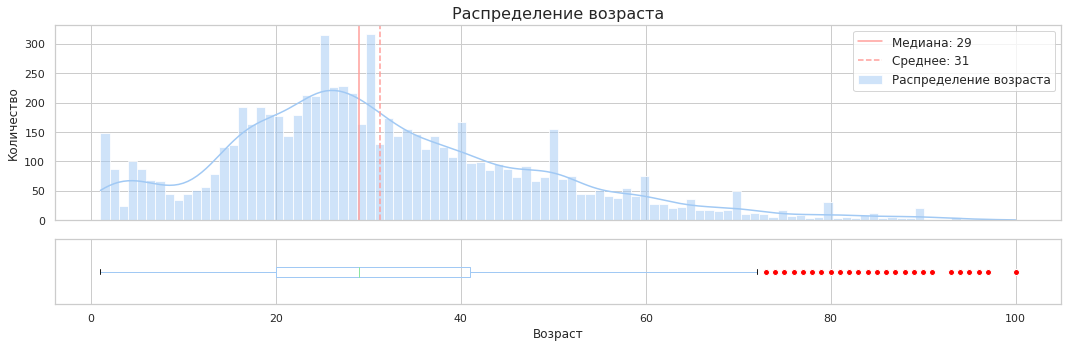

In [ ]:
# применение функции для построения распределения
get_histogram(labels, 'real_age', bins_num=100)

Мы можем видеть два "купола":
- первый от 1 года до приблизительно 8 с провалом в данных в районе 3 лет.
- второй (основной) - от восьми и далее, со смещением центра всего и длинным хвостом справа.

Также мы наблюдаем пики около года, а также для "юбилейных дат" (каждые 5 лет) начиная приблизительно с 25 лет. В связи с чем можно предположить. что хоть и столбец имеет название 'real_age', но в некоторых случаях возраст был указан приблизительный (возможно, с округлением до ближайшей "пятерки"). Проверить, так ли это, а также установить точный возраст изображеннвх на фотографиях людей не представляется возможным. Но это может вызвать сложности в обучении модели, а также наверняка снизит ее точность.

И, как мы уже упоминали ранее, для лиц старшего возраста данных у нас меньше всего. Особенно заметно на гистограмме снижение количества данных для лиц старше 65, что в принципе является естесвенным. Однако это значит, что модели будет сложнее обучиться определять точный возраст для данных лиц. Расширить же выборку для данной категории также не представляется возможным.

Представители "детского купола" не могут нас слишком интересовать как покупатели (то есть в рамках первой задачи), так как большая часть из них не способна самостоятельно совершать покупки (хотя и может влиять на покупки, совершаемые более взрослыми людьми), а имеющиеся у них денежные средства принадлежат чаще всего более взрослым лицам. Также они не слишком нам интересны и для второй задачи (так как их возраст младше 18 очевиден), но все же некоторые продавцы могут оказаться недобросовестны, продавая запрещенные для реализации данной категории лиц товары 6-8 летним детям, отправленными за данной покупкой кем-либо из их близких. К тому же дети разноображивают наш датасет, что может повысить качество обучения модели.

**Вывод**

Мы изучили CSV-файл.

При первичном изучении установлено, что:
- данные содержат 7591 файл, что соответствует информации из документации.
- имена файлов и индексы расположены в таблице по порядку, однако заметно, что некоторые файлы, вероятно, когда-то были удалены.
- имена столбцов соответствуют правилам хорошего тона, а типы данных в них - их содержимому.
- пропусков, а также явных и неявных дубликатов в табличных данных не обнаружено (наличие же дубликатов среди самих изображений не представляется возможным).

Статистическое описание и построение гистограммы распределения показало, что:
- в данных содержатся изображения людей в возрсте от 1 до 100 лет, при этом отсутствуют фотографии людей, чей возраст совтавляет 92, 98, 99 лет.
- имеются смещения распределения в данных (средний возраст составляет 31.2 года, медианный 29).
- много детских фотографий, но основная часть составляет фотографии людей от 20 до 41 года.
- на гистограмме имеется провал "детского купола" в районе 3 лет.
- на гистограмме имеются пики в районе каждых 5 лет, начиная приблизительно с 25 лет.
- лица старшего возраста представлены мало, особенно заметно снижение количества после 65 лет.

Все это (малая представленность некоторых групп, вероятность приблизительного указания возрастов для некоторых изображений) приведет к трудностям в обучении модели, а также снижению качества ее предсказаний. Однако установить, был ли возраст некоторых лиц "округлен" и установить их реальный возраст, а также расширить выборку для малопредставленных групп не представляется возможным.

Представители "детского купола" (которых немало) не могут нас слишком интересовать как покупатели (то есть в рамках первой задачи), так как большая часть из них не способна самостоятельно совершать покупки (хотя и может влиять на покупки, совершаемые более взрослыми людьми), а имеющиеся у них денежные средства принадлежат чаще всего более взрослым лицам. Также они не слишком нам интересны и для второй задачи (так как их возраст младше 18 очевиден), но все же некоторые продавцы могут оказаться недобросовестны, продавая запрещенные для реализации данной категории лиц товары 6-8 летним детям, отправленными за данной покупкой кем-либо из их близких. К тому же дети разноображивают наш датасет, что может повысить качество обучения модели.

## Изображения

Также, согласно заданию проекта, и для лучшего понимания, с чем же мы будем работать, выведем некоторое количество фотографий на экран.

Для обучения мы будем грузить изображения заново, и, возможно, по-другому их обрабатывать (как минимум, разбивать их на тренировочные и тестовые данные). Поэтому для вывода создадим отдельную загрузку (со всеми изображениями).

In [ ]:
# проверочная загрузка изображений
# с нормализацией
check_flow = ImageDataGenerator(rescale=1/255).flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces//final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=RANDOM_STATE,
        )

Found 7591 validated image filenames.


Количество загруженных изображений совпадает с количеством ранее обнаруженных. Теперь выведем некоторое количество фотографий на экран и опишем наблюдаемое в выводах.

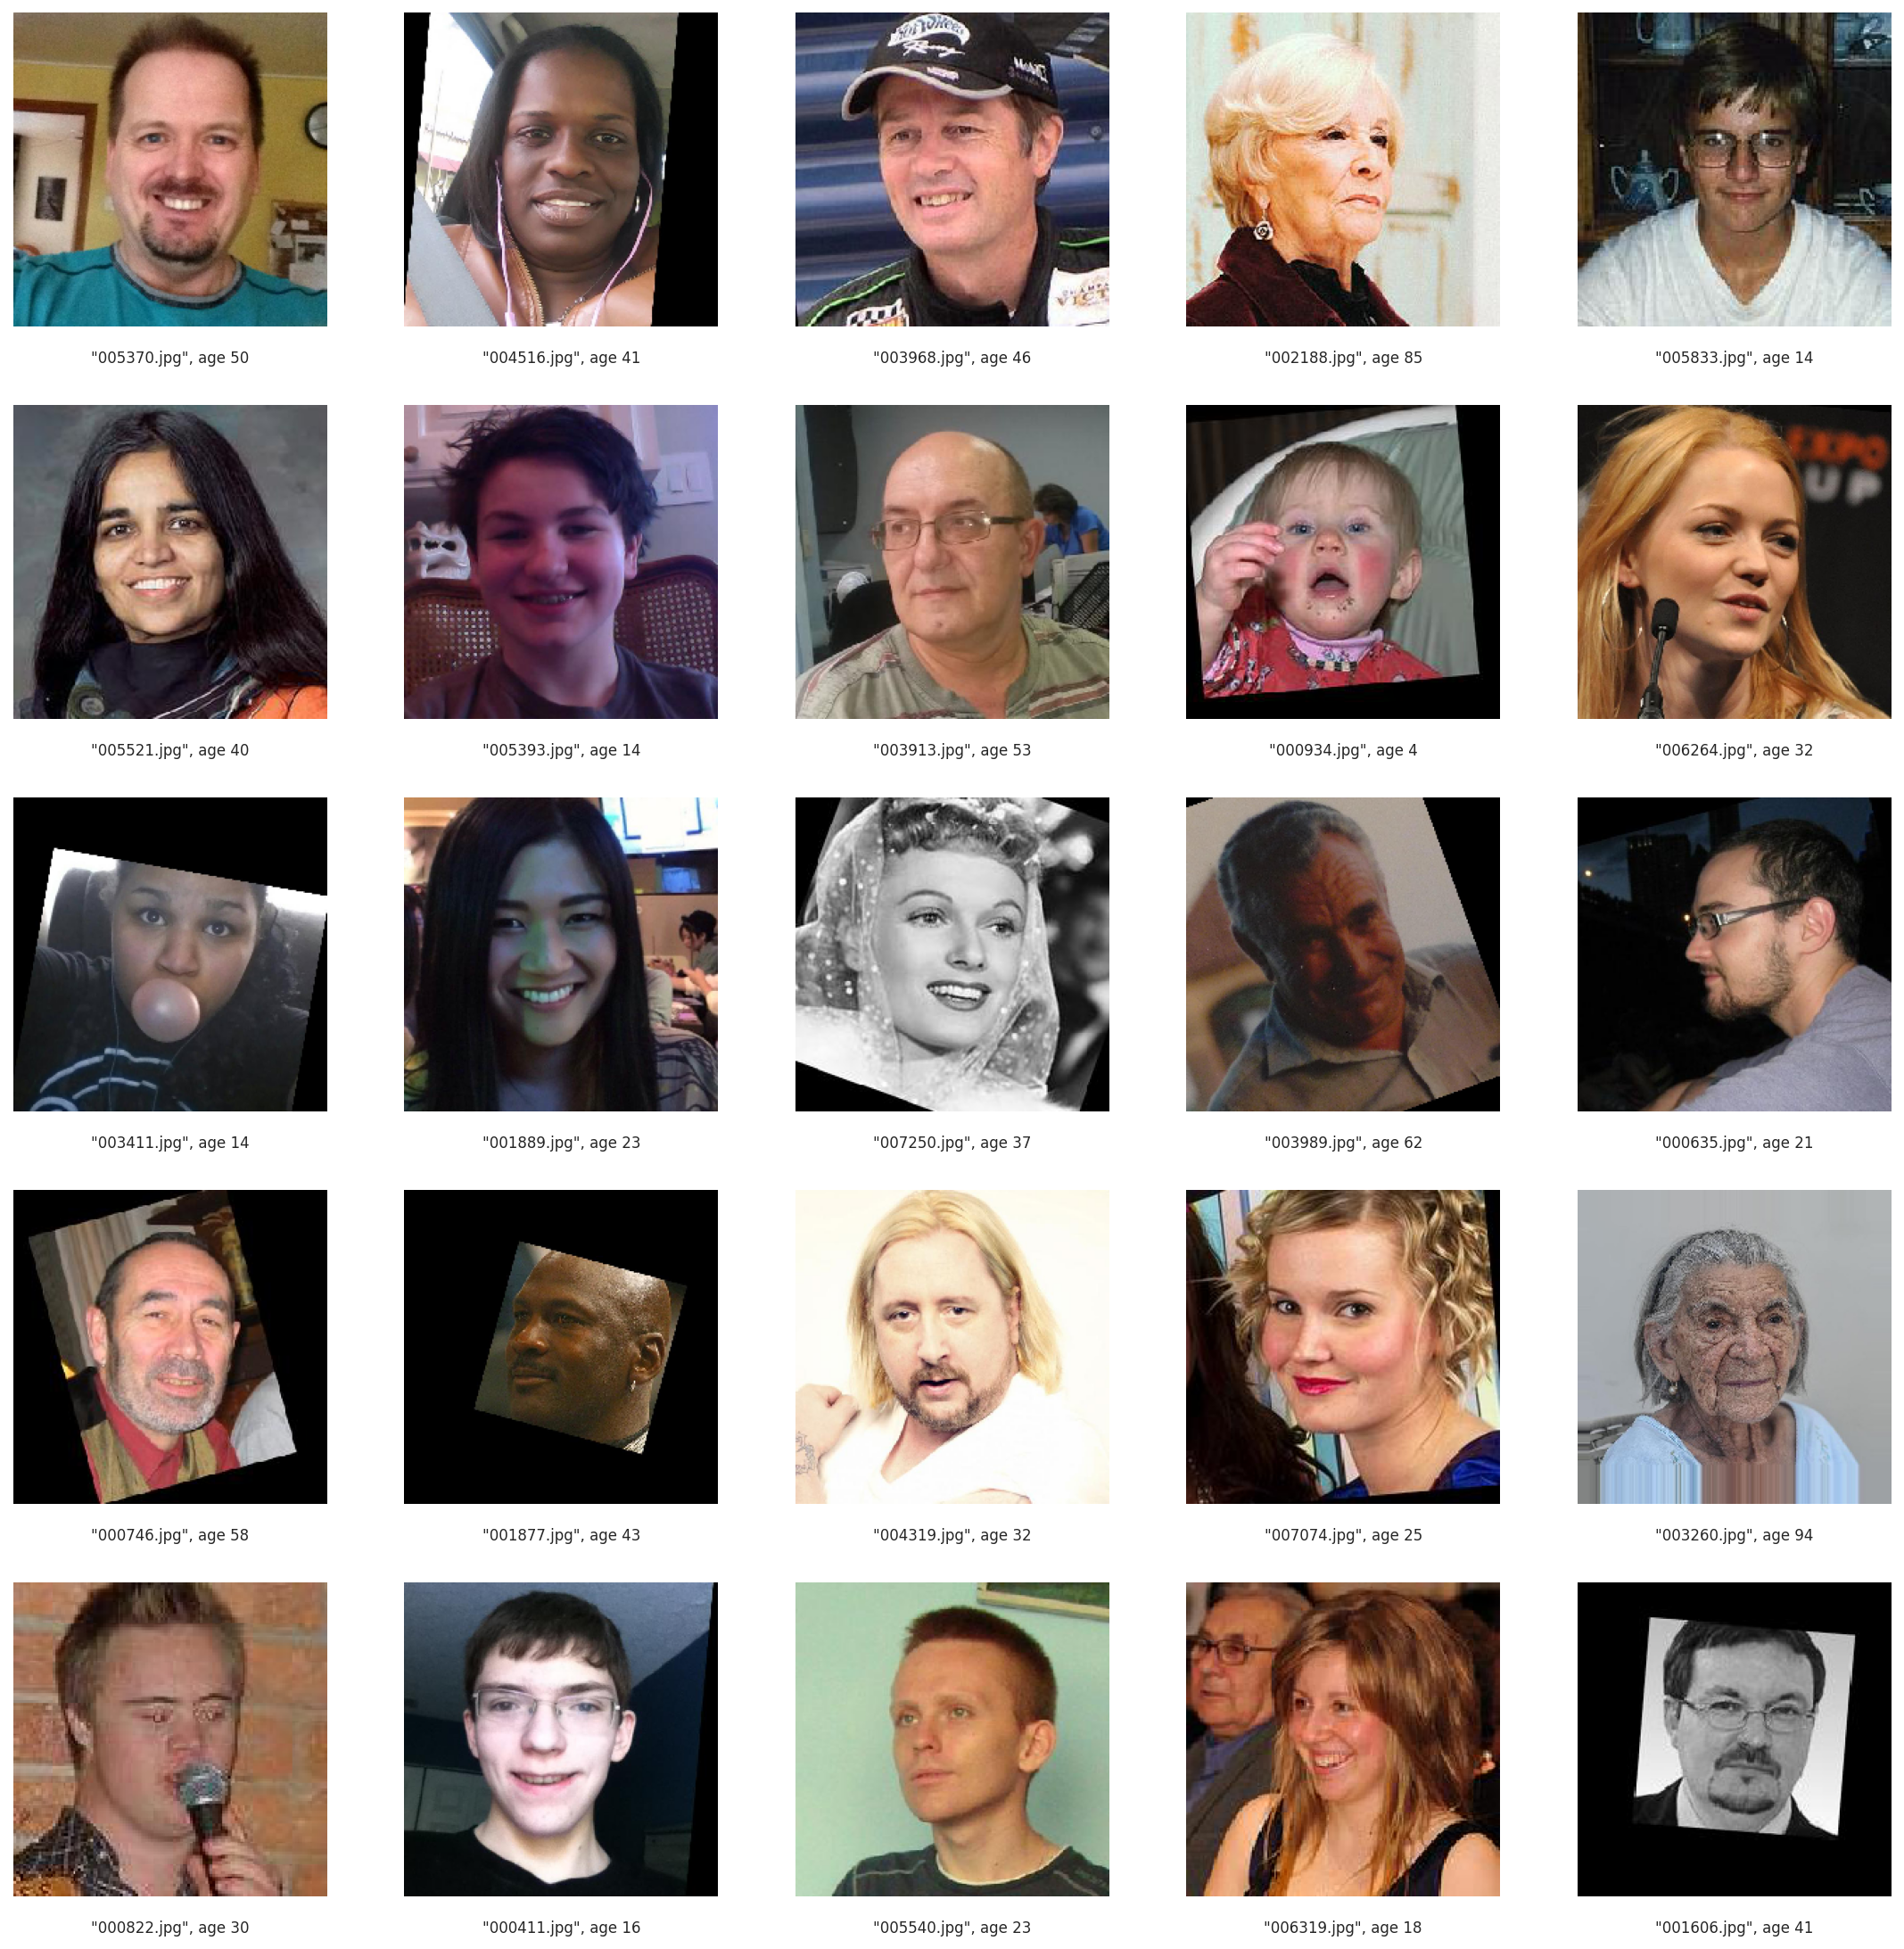

In [ ]:
# вывод изображений
# без создания дополнительных переменных/констант заранее
# создание фигуры для визуализации
fig = plt.figure(figsize=(15, 15), # размер фигуры
                 dpi=150) # разрешение
# цикл добавления каждого изображения на фигуру
for i in range(25): # () количество картин для вывода
    ax = fig.add_subplot(5, 5, i+1)  # указываем колчество строк и столбцов (например, кол-во картинок**0.5)
    plt.imshow(check_flow[0][0][i]) # отображение изображения с индексом i из батча с номером 0 из check_flow
    # подпись под изображением (без осей)
    plt.axis('off') # отключение осей
    # добавление меток и их формат выода
    plt.text(0.5, -0.1, f'"{check_flow.filenames[check_flow.index_array[i]]}", age {check_flow[0][1][i]}',
             ha='center', va='center', transform=ax.transAxes, fontsize=8)
# настраивает макет графиков на фигуре, чтобы они были расположены оптимально и не перекрывались
plt.tight_layout(pad=2.0) # (отступ)
plt.show() # вывод "графика"

**Выводы**

Здесь мы можем наблюдать, что фотографии - разного качества:
- сделаны при разном освещении и в разной обстановке;
- качество (в том числе, четкость) - разные;
- разные "палитры" - есть как цветные, так и черно-белые фотографии;
- на некоторых изображениях может быть несколько людей;
- часть фотографий повернуто (возможно, чтобы разместить лицо под его "нормальным" углом, либо для разноображивания датасета);
- некоторые лица могут быть частично скрыты волосами или предметами;
- не все люди смотрят в камеру;
- люди относятся к разным национальностям и расам.

Это все может как усложнить обучение модели (ввиду проблем с выборками), так и напротив, натренировать ее давать правильные ответы независимо от, например, освещения, угла зрения или помех из предметов.

При этом мы можем наблюдать потенциальноое визуальное соответствие изображения и указанного для него возраста.

**Выводы**

- Данные в наборе распределены неравномерно, поэтому модель может лучше научиться определять возраст средней или младшей группы, но хуже - старшей.

- Разнообразие условий съемки и качества изображений позволят улучшить робастность модели (сохранять качество работы при различных изменениях входных данных).

# Обучение моделей

Перенесем сюда код обучения модели и её результат вывода на экран.

В связи с большим количеством необходимых ресурсов, Код в этом разделе запускался в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке. В нем встречаются как заявленные ранее константы (которые должны были бы использоваться при работе в рамках одной платформы), так и значения из них, которые применялись на самом деле.

Код сюда переносился в том же виде, что и отравлялся на обучение. Однако, в связи с особенностями проверки кода на предпроверке и перед запуском у платформы, на которой происходило обучение (Яндекс.Пратикум, тренажер с GPU), возможно, для воспроизведения может дополнительно потребоваться производить импорты из from tensorflow.keras.layers без использования скобок и пояснительных комментариев (в одну строку), либо отдельными строками каждый по-отдельности (если требуется сохранить комментарии), а также следить за количеством пробелов в отступах.

## Модель с аугументацией

Так как у нас имеются указанные ранее особенности данных,сначала было решено попробовать сеть с аугументацией, чтобы дополнительно разнообразить их.

Здесь приведена модель (с "пояснительными комментариями"), обученная на 10 эпохах, однако для достижения допустимого уровня качества хватит и меньше.

### Код

```python
# загрузка библиотек
import pandas as pd # работа с массивами
from tensorflow.keras.preprocessing.image import ImageDataGenerator # загрузчик данных для изображений
from tensorflow.keras.applications.resnet import ResNet50 # импорт ResNet
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, # пулинг для RusNet
    Dense, # тип слоя (полносвязный), выполняет линейную операцию над входными данными
    Dropout, # слой, случайно выключающий некоторые нейроны, помогает предотвратить переобучение модели
    Flatten # слой, преобразующий многомерный тензор в одномерный
    )
from tensorflow.keras.models import Sequential # базовый класс для создания модели нейронной сети в Keras
from tensorflow.keras.optimizers import Adam # загружаем оптимизатор отдельно, чтобы иметь возможность настройки

# загрузка обучающих данных (путь находится в параметре path)
def load_train(path):
       datagen = ImageDataGenerator( # создание экземпляра генератора данных
           #validation_split=TEST_SIZE,
           validation_split=0.25, # размер валидационной выборки
           rescale=1./255, # нормализация данных
           horizontal_flip=True, # случайное горизонтальное переворачивание
           height_shift_range=0.2, # сдвиг по вертикали (в долях от высоты изображения)
           shear_range=0.3 # (случайное искажение путем сдвига в радианах
     )

     # создание тренировочного
       train_datagen_flow = datagen.flow_from_dataframe(
         pd.read_csv(path + 'labels.csv'), # метки и путь к ним
         path + 'final_files/', # путь к изображениям
         x_col='file_name', # "признаки"
         y_col='real_age', # "целевой признак"
         target_size=(224,224), # "стандартизация" размера изображений
         batch_size=32, # размер батча
         # 'raw' используется, когда метки классов представляют собой непрерывные значения
         # (задачи регресии)
         class_mode='raw',
         subset='training', # указание, что это тренировочная выборка
         #seed=RANDOM_STATE
         seed=12345
         )

       return train_datagen_flow

# загрузка тестовых данных (путь находится в параметре path)
def load_test(path):
      datagen = ImageDataGenerator( # создание экземпляра генератора данных
           #validation_split=TEST_SIZE, # должен совпадать с тренировочной
           validation_split=0.25, # размер валидационной выборки
           rescale=1./255) # нормализация

      test_datagen_flow = datagen.flow_from_dataframe(
         pd.read_csv(path + 'labels.csv'), # метки и путь к ним
         path + 'final_files/', # путь к изображениям
         x_col='file_name', # "признаки"
         y_col='real_age', # "целевой признак"
         target_size=(224,224), # "стандартизация" размера изображений
         batch_size=32, # размер батча
         # 'raw' используется, когда метки классов представляют собой непрерывные значения
         # (задачи регресии)
         class_mode='raw',
         subset='validation', # указание, что это тренировочная выборка
         #seed=RANDOM_STATE
         seed=12345 # должен совпадать с тренировочной
         )
      return test_datagen_flow

# создание модели
# вариант 3.55
def create_model(input_shape):

    # заморозка сети
    backbone = ResNet50(
        input_shape=input_shape,
        # инициализатор весов (imagenet - название датасета на 1000 классов, на котором сеть обучалась классифицировать изображения)
        # Если обучение сети начать на ImageNet, а продолжить какой-то задаче, результат будет лучше, чем если обучать с нуля.
        # Чтобы инициализация весов была случайной, напишите weights=None.
        # weights='imagenet',
        # в нашей задаче веса были предзагружены на сервер, поэтому, чтобы обучение происходило быстрее, укажем путь к ним
        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
        # указание на то, что в конце архитектуры ResNet есть два слоя: GlobalAveragePooling2D и Dense.
        # если задать False, то этих слоёв не будет.
        include_top=False)

    # архитектура слоев сети
    model = Sequential()  # полносвязная
    model.add(backbone)  # заморозка
    # пулинг с окном на весь тензор, чтобы усреднить информацию по всему изображению,
    # то есть получить пиксель с большим количеством каналов
    model.add(GlobalAveragePooling2D())  # актуален для ResNet ввиду особенностей сети
    # для регрессии нужна линейная активация (то есть по факту - отсутствие нелинейного преобразования)
    # т.е. т.к. задача регрессии, функция активации не нужна (вероятность не может быть отрицательной)
    model.add(Dense(1))  # выходной слой

    model.compile(optimizer=Adam(learning_rate=0.0001),  # оптимизатор и параметры
                  # loss=LOSS,
                  loss='mse',  # функция потерь
                  # metrics=METRICS)
                  metrics=['mae'])  # метрика - точность

    return model

# запуск модели
# так как код выполняется на платформе, переменные train_data, test_data берутся оттуда
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                 steps_per_epoch=None, validation_steps=None):
  # для ситуации, если функция вызвана без явной передачи  steps_per_epoch и validation_steps
  # (со значением по умолчанию None), то они примут значения равное длине выборок
  if steps_per_epoch is None:
    steps_per_epoch = len(train_data)
    if validation_steps is None:
      validation_steps = len(test_data)

  model.fit(train_data,
            validation_data=test_data,
            batch_size=batch_size,
            epochs=epochs,
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            verbose=2)

  return model
```

### Результат работы модели

Здесь приведен видимый вывод работы модели (за исключением системных сообщений и предупреждений).

*Выводимый результат работы модели (10 эпох):*
```
Found 5694 validated image filenames.

Found 1897 validated image filenames.

Train for 178 steps, validate for 60 steps

Epoch 1/10

2025-06-09 05:32:36.528937: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2025-06-09 05:32:36.914670: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

178/178 - 97s - loss: 239.5580 - mae: 11.1528 - val_loss: 922.4002 - val_mae: 25.5599

Epoch 2/10

178/178 - 90s - loss: 89.5601 - mae: 7.1702 - val_loss: 766.8647 - val_mae: 22.6776

Epoch 3/10

178/178 - 90s - loss: 65.2759 - mae: 6.1384 - val_loss: 216.1952 - val_mae: 10.6905

Epoch 4/10

178/178 - 89s - loss: 53.8672 - mae: 5.5636 - val_loss: 157.2597 - val_mae: 9.8878

Epoch 5/10

178/178 - 90s - loss: 42.6390 - mae: 5.0131 - val_loss: 82.8349 - val_mae: 6.8603

Epoch 6/10

178/178 - 90s - loss: 35.5806 - mae: 4.6118 - val_loss: 77.5887 - val_mae: 6.5031

Epoch 7/10

178/178 - 90s - loss: 29.6954 - mae: 4.2353 - val_loss: 82.7367 - val_mae: 6.8170

Epoch 8/10

178/178 - 89s - loss: 24.8974 - mae: 3.8444 - val_loss: 64.8700 - val_mae: 6.0091

Epoch 9/10

178/178 - 89s - loss: 22.9031 - mae: 3.7219 - val_loss: 60.3978 - val_mae: 5.8434

Epoch 10/10

178/178 - 90s - loss: 19.4088 - mae: 3.4103 - val_loss: 82.6493 - val_mae: 6.7371

60/60 - 9s - loss: 82.6493 - mae: 6.7371

Test MAE: 6.7371
```

Мы уже достигли требуемого уровня количества (начиная с 5 эпохи интересующая нас метрика качества МАЕ стала меньше 8). Однако было решено увеличить количество эпох до 15, чтобы попробовать улучшить качество еще больше.

К тому же после 9 начали проявляться признаки переобучения (качество на обучаюющих данных растет, а на тренировочных - падает), поэтому решено было подтвердить или опровергнуть наличие переобучения.

*Выводимый результат работы модели (15 эпох):*
```
Found 5694 validated image filenames.

Found 1897 validated image filenames.

Train for 178 steps, validate for 60 steps

Epoch 1/15

2025-06-09 09:10:12.365592: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2025-06-09 09:10:12.822485: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

178/178 - 125s - loss: 244.2861 - mae: 11.2646 - val_loss: 749.3737 - val_mae: 22.4362

Epoch 2/15

178/178 - 92s - loss: 89.1914 - mae: 7.1176 - val_loss: 727.7934 - val_mae: 21.8662

Epoch 3/15

178/178 - 93s - loss: 64.9814 - mae: 6.1231 - val_loss: 341.0223 - val_mae: 13.5090

Epoch 4/15

178/178 - 93s - loss: 50.3367 - mae: 5.4527 - val_loss: 120.6748 - val_mae: 8.4356

Epoch 5/15

178/178 - 94s - loss: 42.3163 - mae: 4.9704 - val_loss: 112.2314 - val_mae: 8.0168

Epoch 6/15

178/178 - 92s - loss: 36.2492 - mae: 4.6324 - val_loss: 75.2567 - val_mae: 6.4971

Epoch 7/15

178/178 - 92s - loss: 29.9806 - mae: 4.2195 - val_loss: 75.2142 - val_mae: 6.5046

Epoch 8/15

178/178 - 94s - loss: 26.6640 - mae: 3.9677 - val_loss: 78.3846 - val_mae: 6.3675

Epoch 9/15

178/178 - 94s - loss: 22.6348 - mae: 3.6671 - val_loss: 73.4748 - val_mae: 6.5835

Epoch 10/15

178/178 - 93s - loss: 20.1181 - mae: 3.4411 - val_loss: 84.6071 - val_mae: 6.8083

Epoch 11/15

178/178 - 94s - loss: 17.3480 - mae: 3.2073 - val_loss: 63.8889 - val_mae: 5.8640

Epoch 12/15

178/178 - 93s - loss: 16.6047 - mae: 3.0885 - val_loss: 66.1077 - val_mae: 5.9174

Epoch 13/15

178/178 - 93s - loss: 15.1742 - mae: 3.0175 - val_loss: 59.8455 - val_mae: 5.6788

Epoch 14/15

178/178 - 94s - loss: 14.0307 - mae: 2.8592 - val_loss: 79.6820 - val_mae: 6.5824

Epoch 15/15

178/178 - 93s - loss: 12.1829 - mae: 2.6987 - val_loss: 68.6813 - val_mae: 6.0703

60/60 - 10s - loss: 68.6813 - mae: 6.0703

Test MAE: 6.0703
```

Качество модели улучшилось (несмотря на риски переобучения), но стало требовать больше времени на свое обучение. К тому же сохраняется риск переобучения.

Попробуем применить эту же модель на 7 эпохах.

*Выводимый результат работы модели (7 эпох):*
```
Found 5694 validated image filenames.

Found 1897 validated image filenames.

Epoch 1/7

2025-06-09 12:03:42.564613: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2025-06-09 12:03:43.683109: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

178/178 - 122s - loss: 243.1515 - mae: 11.0470 - val_loss: 800.3812 - val_mae: 23.3745

Epoch 2/7

178/178 - 90s - loss: 86.6172 - mae: 7.0668 - val_loss: 772.2398 - val_mae: 22.7153

Epoch 3/7

178/178 - 90s - loss: 64.5466 - mae: 6.1299 - val_loss: 261.2832 - val_mae: 11.8888

Epoch 4/7

178/178 - 90s - loss: 52.5715 - mae: 5.5863 - val_loss: 119.1090 - val_mae: 8.4530

Epoch 5/7

178/178 - 89s - loss: 40.0689 - mae: 4.8373 - val_loss: 83.9729 - val_mae: 6.8922

Epoch 6/7

178/178 - 89s - loss: 36.3048 - mae: 4.5939 - val_loss: 68.1711 - val_mae: 6.1449

Epoch 7/7

178/178 - 89s - loss: 29.3355 - mae: 4.1590 - val_loss: 67.5131 - val_mae: 6.1329

60/60 - 9s - loss: 67.5131 - mae: 6.1329

Test MAE: 6.1329
```

Метрика немного хуже, чем 15 эпох, но гораздо лучше 10. При этом обучение проходит быстрее, что может быть важно.

## Модель без аугументации

Аугументация отнимает дополнительное время на обучение, но достигает требуемого уровня качества уже от 5-6 эпохи, затем уровень качества растет еще больше (но при этом имеется риск переобучения).

Попробуем применить модель без аугументации на тех же 7 эпохах.

### Код

```python
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet import ResNet50
import pandas as pd

def load_train(path):
    
    train_datagen = ImageDataGenerator(validation_split=0.25, rescale=1/255.)
    labels = pd.read_csv(path + 'labels.csv')
    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345)
    
    return train_gen_flow

def load_test(path):
    
    validation_datagen = ImageDataGenerator(validation_split=0.25, rescale=1/255.)
    labels = pd.read_csv(path + 'labels.csv')
    val_gen_flow = validation_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345)
    
    return val_gen_flow

def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
                        include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1))   
    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mean_absolute_error'])
    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=7,
               steps_per_epoch=None, validation_steps=None):

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2, shuffle=True)
    return model
```

### Результат работы модели

```
Found 5694 validated image filenames.

Found 1897 validated image filenames.

Epoch 1/7

2025-06-09 11:16:33.271823: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2025-06-09 11:16:34.807091: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

178/178 - 74s - loss: 231.7279 - mean_absolute_error: 10.8442 - val_loss: 1000.5700 - val_mean_absolute_error: 26.9300

Epoch 2/7

178/178 - 37s - loss: 61.3008 - mean_absolute_error: 5.9220 - val_loss: 998.4094 - val_mean_absolute_error: 26.9082

Epoch 3/7

178/178 - 38s - loss: 30.8251 - mean_absolute_error: 4.2890 - val_loss: 333.7302 - val_mean_absolute_error: 13.4761

Epoch 4/7

178/178 - 37s - loss: 20.1108 - mean_absolute_error: 3.4589 - val_loss: 104.6010 - val_mean_absolute_error: 7.7133

Epoch 5/7

178/178 - 37s - loss: 14.5229 - mean_absolute_error: 2.9255 - val_loss: 101.6207 - val_mean_absolute_error: 7.6257

Epoch 6/7

178/178 - 38s - loss: 12.4281 - mean_absolute_error: 2.7322 - val_loss: 89.5926 - val_mean_absolute_error: 7.5003

Epoch 7/7

178/178 - 37s - loss: 11.5038 - mean_absolute_error: 2.5837 - val_loss: 73.7491 - val_mean_absolute_error: 6.3449

60/60 - 9s - loss: 73.7491 - mean_absolute_error: 6.3449

Test MAE: 6.3449
```

За семь эпох модель также достигает хорошего уровня качества, хотя ее метрика и хуже, чем у модели с аугументацией на том же количестве эпох (причем требуемых - уже на 4)

Однако она уже не требует дополнительных ресурсов на аугументацию, и обучается гораздо быстрее, чем более точная с аугументацией.

## Анализ обученных моделей

В данной работе исследовались модели на основе свёрточной сети ResNet50 предобученной на наборе изображений ImageNet. В качества головы были использованы слой GlobalAveragePooling2D а также полносвязный слой с одним выходом и без функции активации. Функция потерь была MSE, метрика качества - MAE. Размер батча - 32 изображения. Требуемый уровень для отличного качества - MAE<7, на который мы ориентировались (однако минимальный требуемый уровень качества MAE<8).

В ходе подбора оптимальных параметров мы перебирали:

- наличие и отсутствие аугментаций;
- количество эпох (для варианта с аугументацией).

В результате мы обнаружили:

- Модель с аугументацией дает на 10 эпохах требуемый уровень качества, увеличение количества эпох до 15 повышает метрику, но обучается медленнее (тратит больше ресурсов) и создает риск переобучения. При этом на 7 эпохах метрика хуже 15, но лучше 10 эпох.
- Оба варианта (с аугументацией и без нее) достигали к эпохе 7 требуемого уровня качества.
- Модель без аугументации на 7 эпохах дает несколько меньшую метрику, чем с ней на том же количестве эпох, однако обучается быстрее (экономия ресурсов).

Исходя из этого, модель с аугументацией на 10 эпохах однозначно можно признать худшей из обученных (тратит ресурсы на аугументацию и обучается дольше, чем без, ри этом метрика хуже, чем у такой же модели и у модели без аугументации на 7 эпохах).

И в зависимости от имеющихся у нас ресурсов и необходимой степени точности можно выбрать разные модели из оставшихся трех:
- при ограниченных ресурсах - без аугументации;
- при наличии ресурсов - с аугументацией на 7 или 15 эпох в зависимости от желаемого уровня точности.

## Выводы

- Мы изучили полученные изображения и выявили их неоднородность (по качеству и иным параметрам изображений) и несбалансированность (по представленным возрастам).
- На имеющихся данных мы обучили несколько моделей на основе ResNet.
- Все модели достигли требуемого уровня отличного качества (MAE<7).
- Одна из моделей по совокупности факторов (ресурсоемкость и наиболее низкая метрика) оказалась однозначно хуже остальных.
- Какую из трех оставшихся выбрать для задачи, зависит от имеющихся в распоряжении ресурсов и необходимого уровня точности.
- С учетом анализа данных и качесва моделей, можно предположить, что модель можно использовать для рекомендаций, но контролировать с ее помощью добросовестность продавцов при продаже товаров с "возрастным цензом" будет затруднительно ввиду возможной большой (для данной задачи) погрешности результата.